In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving SMSSpamCollection to SMSSpamCollection


In [3]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


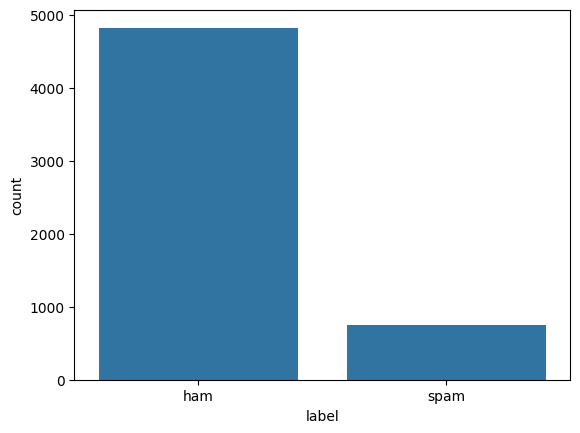

In [7]:
sns.countplot(data=df, x="label")
plt.show()

In [8]:
df["label"] = df["label"].map({
    "ham":0,
    "spam":1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
X = df["message"]

y = df["label"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [13]:
predictions = model.predict(X_test)

predictions

array([0, 0, 0, ..., 0, 0, 0])

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print(accuracy)

0.9668161434977578


In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



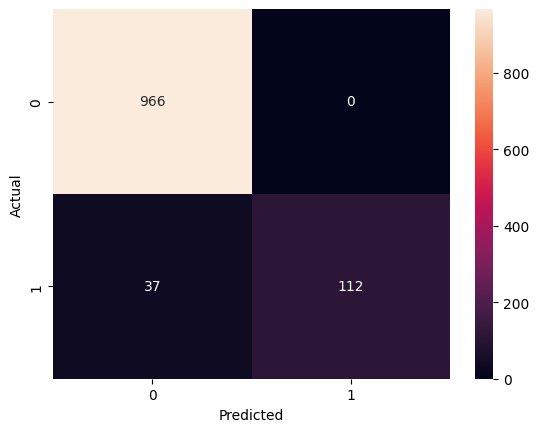

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
msg = [
    "Congratulations! You won a free iPhone."
]

msg_vector = vectorizer.transform(msg)

result = model.predict(msg_vector)

if result[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


In [18]:
prob = model.predict_proba(msg_vector)

print(prob)

[[0.3737053 0.6262947]]


In [19]:
!pip install gradio

In [20]:
def predict_spam(message):

    message_vector = vectorizer.transform([message])

    prediction = model.predict(message_vector)[0]

    probability = model.predict_proba(message_vector)[0]

    if prediction == 1:
        return f"🚨 Spam\nConfidence: {probability[1]*100:.2f}%"
    else:
        return f"✅ Not Spam (Ham)\nConfidence: {probability[0]*100:.2f}%"

In [21]:
import gradio as gr

interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type your message here..."
    ),
    outputs="text",
    title="📧 Spam Email Classifier",
    description="Enter a message and the AI model will predict whether it is Spam or Ham."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e626d78e3e17c68d94.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        label="SMS Message",
        lines=4
    ),
    outputs=gr.Textbox(
        label="Prediction"
    ),
    title="📧 AI Spam Detector",

)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9142d3b67af4551797.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
